In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
df = pd.read_csv('dbl_south_region_boys_games.csv')

In [ ]:
df.info

<bound method DataFrame.info of      game_id        date  season_year            series        region  \
0        807  2019-08-31         2019  East Java Series  South Region   
1        808  2019-08-31         2019  East Java Series  South Region   
2        809  2019-08-31         2019  East Java Series  South Region   
3        810  2019-08-31         2019  East Java Series  South Region   
4        821  2019-09-01         2019  East Java Series  South Region   
..       ...         ...          ...               ...           ...   
366    12292  2026-09-01         2026  East Java Series  South Region   
367    12293  2026-09-01         2026  East Java Series  South Region   
368    12317  2026-09-02         2026  East Java Series  South Region   
369    12319  2026-09-02         2026  East Java Series  South Region   
370    12400  2026-09-04         2026  East Java Series  South Region   

    category                     round                 venue time_wib  \
0       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    15:00   
1       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    16:10   
2       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    17:20   
3       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    18:30   
4       Boys  Group Stage (Penyisihan)  GOR Bimasakti Malang    10:00   
..       ...                       ...                   ...      ...   
366     Boys                     Big 8   GOR Ken Arok Malang    17:30   
367     Boys                     Big 8   GOR Ken Arok Malang    19:00   
368     Boys               Fantastic 4   GOR Ken Arok Malang    16:30   
369     Boys               Fantastic 4   GOR Ken Arok Malang    18:45   
370     Boys                     Final   GOR Ken Arok Malang    17:30   

                             home_team                       away_team  \
0                    MAN 2 KOTA MALANG                   SMAN 4 MALANG   
1        SMA KOLESE SANTO YUSUP MALANG               MAN 1 KOTA MALANG   
2                        SMAN 8 MALANG                  SMAN 10 MALANG   
3                        SMAN 3 MALANG                   SMAN 9 MALANG   
4    SMA BRAWIJAYA SMART SCHOOL MALANG                   SMAN 3 BLITAR   
..                                 ...                             ...   
366                  SMAN 1 BULULAWANG                   SMAN 3 MALANG   
367     CHARIS NATIONAL ACADEMY MALANG                   SMAN 1 LAWANG   
368                      SMAN 3 BLITAR               SMAN 1 BULULAWANG   
369                      SMAN 1 BLITAR  CHARIS NATIONAL ACADEMY MALANG   
370                      SMAN 1 BLITAR               SMAN 1 BULULAWANG   

     home_score  away_score                          winner  margin  \
0            24          15               MAN 2 KOTA MALANG       9   
1            51          12   SMA KOLESE SANTO YUSUP MALANG      39   
2            33          26                   SMAN 8 MALANG       7   
3            33          16                   SMAN 3 MALANG      17   
4            32          37                   SMAN 3 BLITAR       5   
..          ...         ...                             ...     ...   
366          28          21               SMAN 1 BULULAWANG       7   
367          64          12  CHARIS NATIONAL ACADEMY MALANG      52   
368          39          49               SMAN 1 BULULAWANG      10   
369          72          64                   SMAN 1 BLITAR       8   
370          42          49               SMAN 1 BULULAWANG       7   

                                source_url  
0      https://www.dbl.id/match/detail/807  
1      https://www.dbl.id/match/detail/808  
2      https://www.dbl.id/match/detail/809  
3      https://www.dbl.id/match/detail/810  
4      https://www.dbl.id/match/detail/821  
..                                     ...  
366  https://www.dbl.id/match/detail/12292  
367  https://www.dbl.id/match/detail/12293  
368  https://www.dbl.id/match/detail/12317  
369  https://www.dbl.i

In [ ]:
df.shape

(371, 16)

In [ ]:
df.head()
df.tail()

,game_id,date,season_year,series,region,category,round,venue,time_wib,home_team,away_team,home_score,away_score,winner,margin,source_url
366,12292,2026-09-01,2026,East Java Series,South Region,Boys,Big 8,GOR Ken Arok Malang,17:30,SMAN 1 BULULAWANG,SMAN 3 MALANG,28,21,SMAN 1 BULULAWANG,7,https://www.dbl.id/match/detail/12292
367,12293,2026-09-01,2026,East Java Series,South Region,Boys,Big 8,GOR Ken Arok Malang,19:00,CHARIS NATIONAL ACADEMY MALANG,SMAN 1 LAWANG,64,12,CHARIS NATIONAL ACADEMY MALANG,52,https://www.dbl.id/match/detail/12293
368,12317,2026-09-02,2026,East Java Series,South Region,Boys,Fantastic 4,GOR Ken Arok Malang,16:30,SMAN 3 BLITAR,SMAN 1 BULULAWANG,39,49,SMAN 1 BULULAWANG,10,https://www.dbl.id/match/detail/12317
369,12319,2026-09-02,2026,East Java Series,South Region,Boys,Fantastic 4,GOR Ken Arok Malang,18:45,SMAN 1 BLITAR,CHARIS NATIONAL ACADEMY MALANG,72,64,SMAN 1 BLITAR,8,https://www.dbl.id/match/detail/12319
370,12400,2026-09-04,2026,East Java Series,South Region,Boys,Final,GOR Ken Arok Malang,17:30,SMAN 1 BLITAR,SMAN 1 BULULAWANG,42,49,SMAN 1 BULULAWANG,7,https://www.dbl.id/match/detail/12400


In [ ]:
df.describe()

,game_id,season_year,home_score,away_score,margin
count,371.000000,371.000000,371.000000,371.000000,371.000000
mean,5958.571429,2023.196765,31.239892,28.997305,19.045822
std,3648.958506,2.275983,15.979011,15.687747,15.489336
min,807.000000,2019.000000,5.000000,0.000000,1.000000
25%,3044.500000,2022.000000,19.000000,18.000000,7.000000
50%,6351.000000,2024.000000,28.000000,25.000000,15.000000
75%,8364.500000,2025.000000,39.500000,37.000000,26.000000
max,12400.000000,2026.000000,84.000000,101.000000,95.000000


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2) #pct = percentage
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).head(10)

,missing_count,missing_pct
game_id,0,0.0
date,0,0.0
season_year,0,0.0
series,0,0.0
region,0,0.0
category,0,0.0
round,0,0.0
venue,0,0.0
time_wib,0,0.0
home_team,0,0.0


In [ ]:
#handle missing value numerikal dengan groupby
df_cpy_num1 = df.copy()
home_score_by_away_score = df_cpy_num1.groupby('away_score')['home_score'].transform('median')
df_cpy_num1['home_score'] = df_cpy_num1['home_score'].fillna(home_score_by_away_score)

df_cpy_num1[['home_score']].isna().sum()

,0
home_score,0


In [ ]:
#handle massing value kategorikal
df_cpy_cat1 = df.copy()

df_cpy_cat1['home_team'] = df_cpy_cat1['home_team'].fillna(
    df_cpy_cat1.groupby('away_team')['home_team'].transform(
        lambda x: x.mode().iloc[0])
)

df_cpy_cat1['winner'] = df_cpy_cat1['winner'].fillna('Unknown')
df_cpy_cat1[['home_team','winner']].isna().sum()

,0
home_team,0
winner,0


In [ ]:
df_num = df.copy()

num_cols = ['home_score','away_score']
print(df_num[num_cols].isna().sum())

home_score    0
away_score    0
dtype: int64


In [ ]:
num_imputer = SimpleImputer(strategy='median')
df_num[num_cols] = num_imputer.fit_transform(df_num[num_cols])
print(df_num[num_cols].isna().sum())

home_score    0
away_score    0
dtype: int64


In [ ]:
#handle missing value kategorikal menggunakan SImpleImputer
df_cat = df.copy()

cat_cols = ['home_team','winner']
for c in cat_cols:
  print('\n',c)
  print(df_cat[c].value_counts(dropna=False).head(10))


 home_team
home_team
SMAN 1 BLITAR                        23
SMA KOLESE SANTO YUSUP MALANG        20
SMA SANTO ALBERTUS MALANG            18
SMAN 3 BLITAR                        18
SMAN 8 MALANG                        17
MAN 2 KOTA MALANG                    16
SMA BRAWIJAYA SMART SCHOOL MALANG    14
SMAN 2 PASURUAN                      13
CHARIS NATIONAL ACADEMY MALANG       13
SMAN 3 MALANG                        12
Name: count, dtype: int64

 winner
winner
SMAN 1 BLITAR                     33
SMA KOLESE SANTO YUSUP MALANG     31
SMAN 8 MALANG                     26
SMAN 3 BLITAR                     26
SMA SANTO ALBERTUS MALANG         24
MAN 2 KOTA MALANG                 20
SMAN 1 BULULAWANG                 18
CHARIS NATIONAL ACADEMY MALANG    16
SMAN 2 PASURUAN                   14
SMAN 3 MALANG                     14
Name: count, dtype: int64


In [ ]:
mf_imputer = SimpleImputer(strategy='most_frequent')
df_cat[['home_team','winner']] = mf_imputer.fit_transform(df_cat[['home_team','winner']])

cabin_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
df_cat[['home_team']] = cabin_imputer.fit_transform(df_cat[['home_team']])
df_cat[cat_cols].isna().sum()

,0
home_team,0
winner,0


In [ ]:
df[num_cols] = df_cpy_num1[num_cols]
df[cat_cols] = df_cpy_cat1[cat_cols]

In [ ]:
#handle value dupe
print('full row dupe:', df.duplicated().sum())
subset_key = ['home_team', 'away_team', 'home_score', 'away_score']
print('subset row dupe:', df.duplicated(subset=subset_key).sum())
df = df.drop_duplicates()
print('after drop_duplicates:',df.shape)

full row dupe: 0
subset row dupe: 0
after drop_duplicates: (371, 16)


In [ ]:
#memperbaiki tipe data
print('before:')
print(df.dtypes)

before:
game_id         int64
date           object
season_year     int64
series         object
region         object
category       object
round          object
venue          object
time_wib       object
home_team      object
away_team      object
home_score      int64
away_score      int64
winner         object
margin          int64
source_url     object
dtype: object


In [ ]:
to_num_cols = [
    'home_score','away_score','margin','season_year'
]
for col in to_num_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print('after:')
print(df.dtypes)

after:
game_id         int64
date           object
season_year     int64
series         object
region         object
category       object
round          object
venue          object
time_wib       object
home_team      object
away_team      object
home_score      int64
away_score      int64
winner         object
margin          int64
source_url     object
dtype: object


In [ ]:
cat_cols = ['home_team','away_team','winner','round']
df['home_team'] = df['home_team'].astype('str').str.strip().str.lower().astype('category')
df['away_team'] = df['away_team'].astype('str').str.strip().str.lower().astype('category')
df['winner'] = df['winner'].astype('str').str.strip().str.lower().astype('category')
df['round'] = df['round'].astype('str').str.strip().str.lower().astype('category')

In [ ]:
print('before cleaning')
categorical_cols = ['home_team','away_team','winner','round']
for c in categorical_cols:
  print('\n',c)
  print(df[c].value_counts(dropna=False).head(10))

df['home_team'] = df['home_team'].astype('string').str.strip().str.lower()
df['away_team'] = df['away_team'].astype('string').str.strip().str.lower()
df['winner'] = df['winner'].astype('string').str.strip().str.title()
df['round'] = df['round'].astype('string').str.strip().str.lower()

print('\nafter cleaning')
for c in categorical_cols:
  print('\n',c)
  print(df[c].value_counts(dropna=False).head(10))

before cleaning

 home_team
home_team
sman 1 blitar                        23
sma kolese santo yusup malang        20
sma santo albertus malang            18
sman 3 blitar                        18
sman 8 malang                        17
man 2 kota malang                    16
sma brawijaya smart school malang    14
charis national academy malang       13
sman 2 pasuruan                      13
sman 3 malang                        12
Name: count, dtype: int64

 away_team
away_team
sman 1 bululawang                 17
sma kolese santo yusup malang     16
sman 3 blitar                     15
charis national academy malang    14
man 2 kota malang                 14
sman 8 malang                     14
sma santo albertus malang         13
sman 1 blitar                     13
sman 4 pasuruan                   13
sman 10 malang                    12
Name: count, dtype: int64

 winner
winner
sman 1 blitar                     33
sma kolese santo yusup malang     31
sman 8 malang               

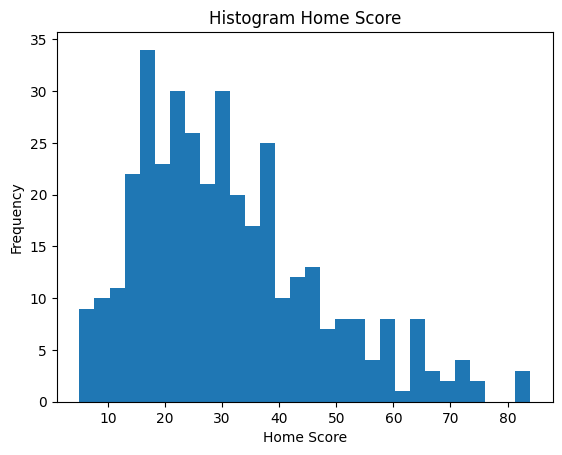

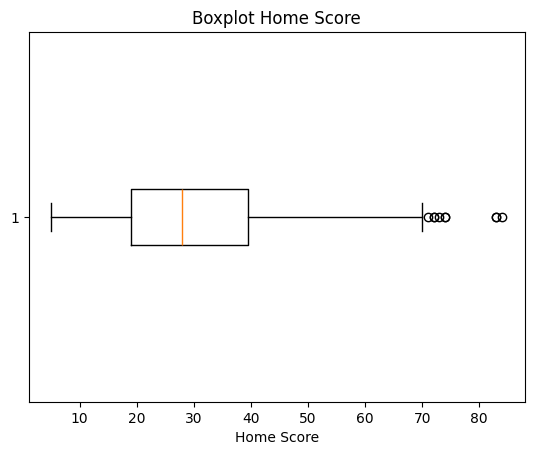

In [ ]:
#boxplot dan histogram
num_cols = ['home_score','away_Score']

#1. Distribusi Home Score
plt.figure
plt.hist(df['home_score'].dropna(),bins=30)
plt.title('Histogram Home Score')
plt.xlabel('Home Score')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.boxplot(df['home_score'].dropna(),vert=False)
plt.title('Boxplot Home Score')
plt.xlabel('Home Score')
plt.show()

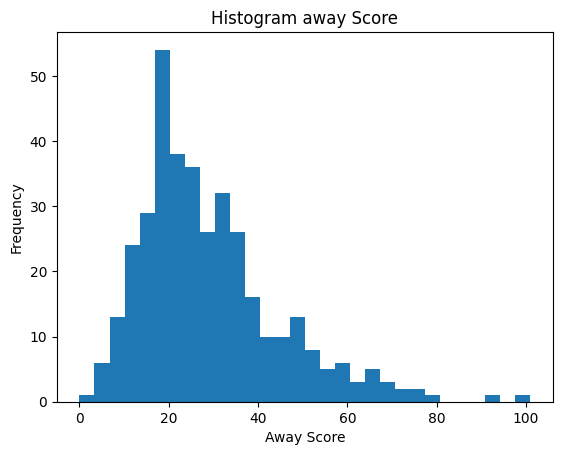

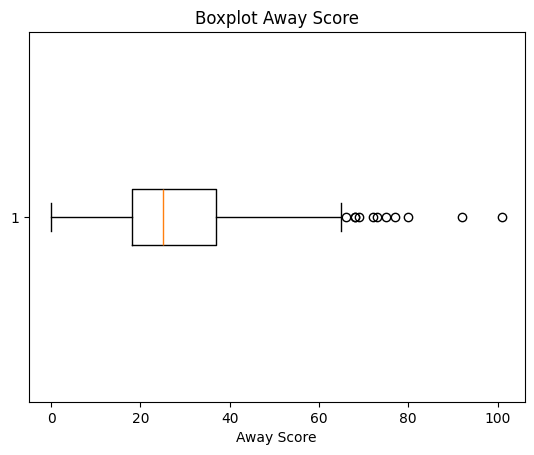

In [ ]:
#2. Distribusi Away Score
plt.figure
plt.hist(df['away_score'].dropna(),bins=30)
plt.title('Histogram away Score')
plt.xlabel('Away Score')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.boxplot(df['away_score'].dropna(),vert=False)
plt.title('Boxplot Away Score')
plt.xlabel('Away Score')
plt.show()

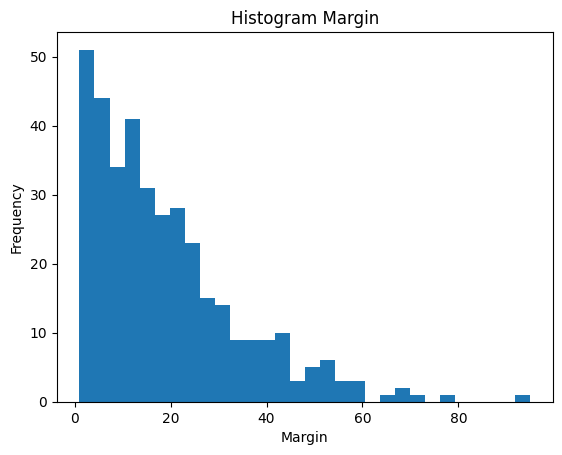

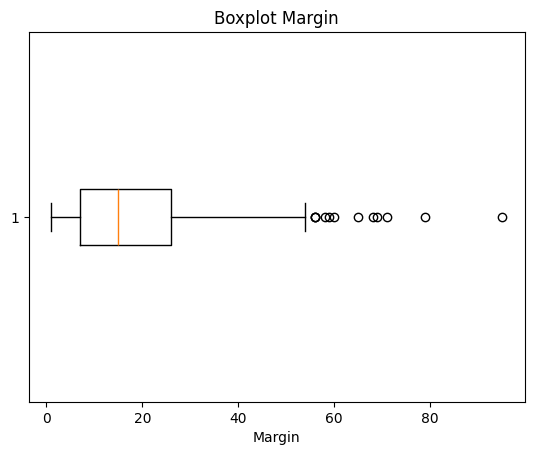

In [ ]:
#3. Distribusi Home Score
plt.figure
plt.hist(df['margin'].dropna(),bins=30)
plt.title('Histogram Margin')
plt.xlabel('Margin')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.boxplot(df['margin'].dropna(),vert=False)
plt.title('Boxplot Margin')
plt.xlabel('Margin')
plt.show()

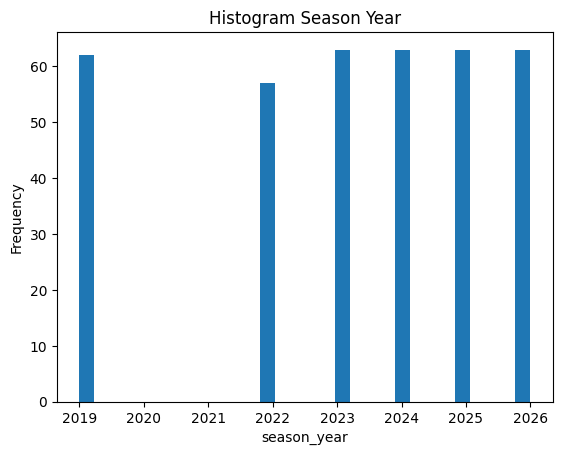

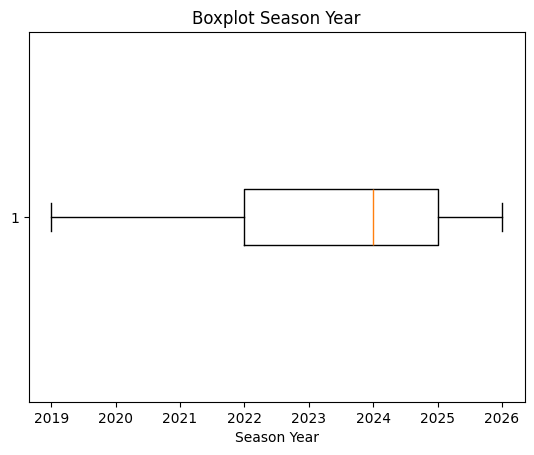

In [ ]:
#4. Distribusi Home Score
plt.figure
plt.hist(df['season_year'].dropna(),bins=30)
plt.title('Histogram Season Year')
plt.xlabel('season_year')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.boxplot(df['season_year'].dropna(),vert=False)
plt.title('Boxplot Season Year')
plt.xlabel('Season Year')
plt.show()

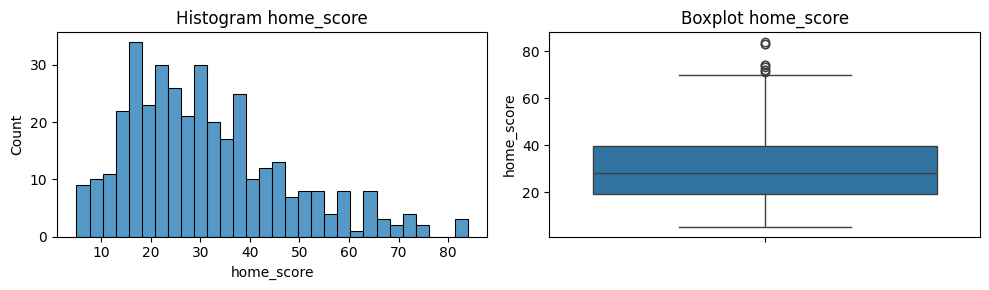

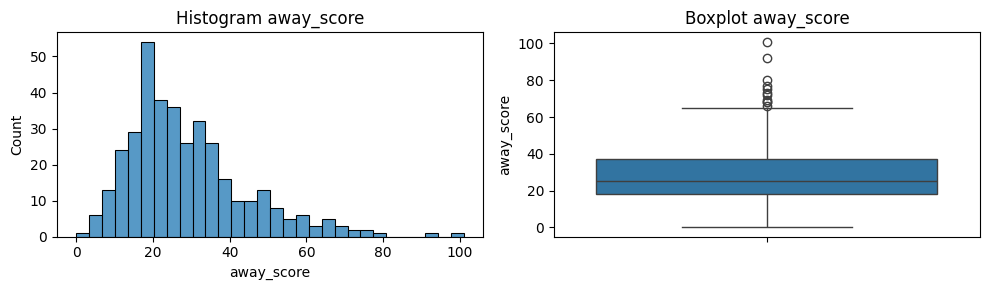

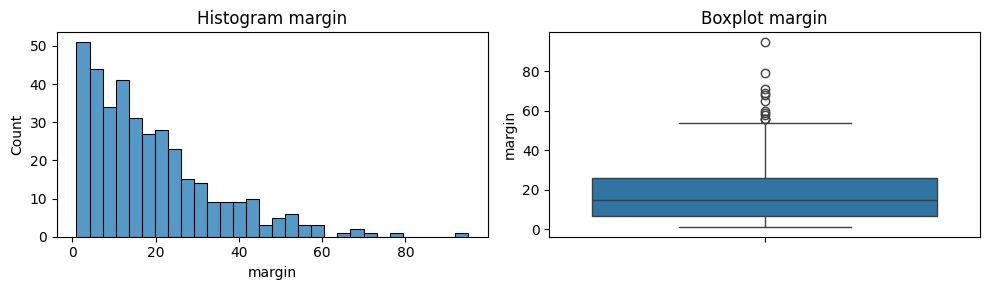

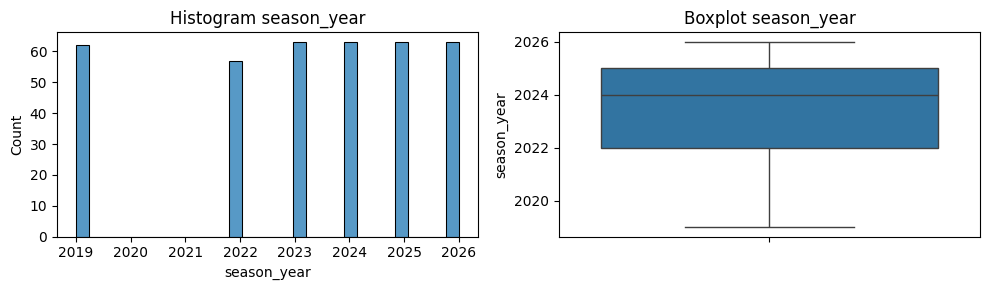

In [ ]:
#parch
import seaborn as sns
num_cols = ['home_score','away_score','margin','season_year']

for col in num_cols:
  fig,axes = plt.subplots(1,2, figsize=(10,3))
  sns.histplot(df[col].dropna(), bins=30, ax=axes[0])
  axes[0].set_title(f'Histogram {col}')

  sns.boxplot(df[col].dropna(), ax=axes[1])
  axes[1].set_title(f'Boxplot {col}')

  plt.tight_layout()
  plt.show()

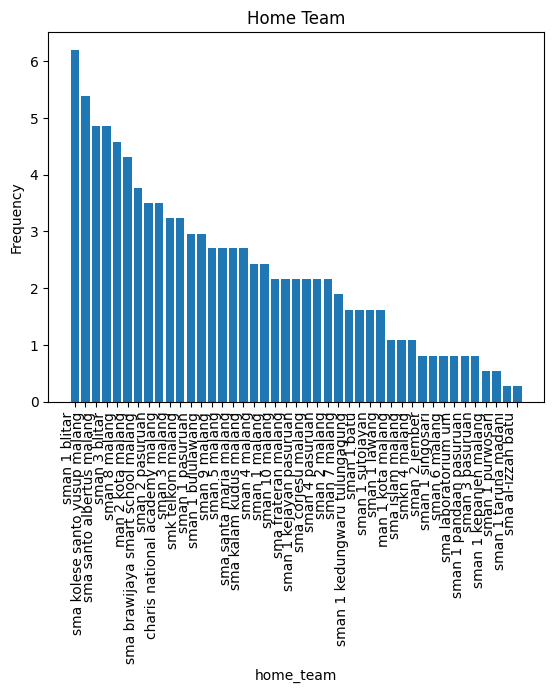

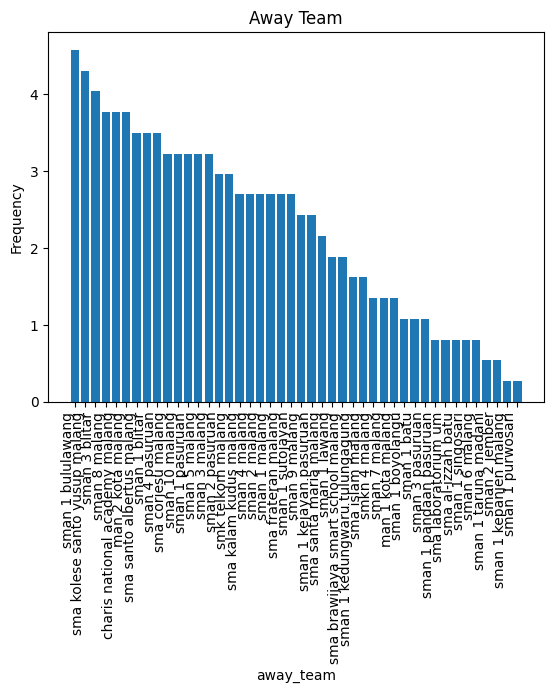

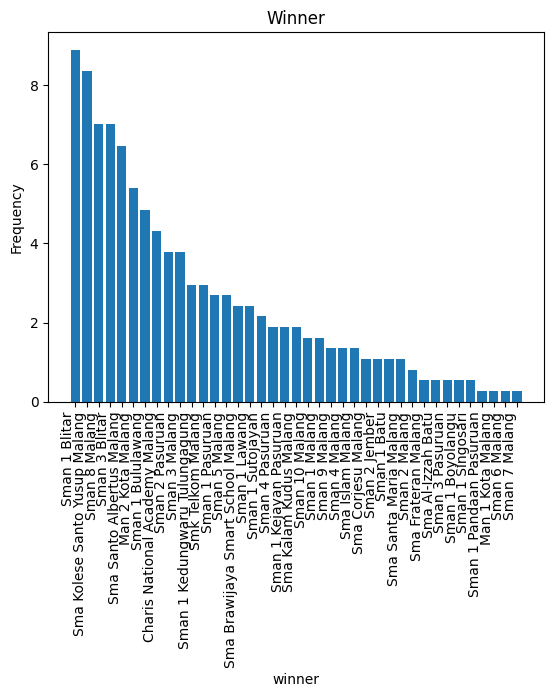

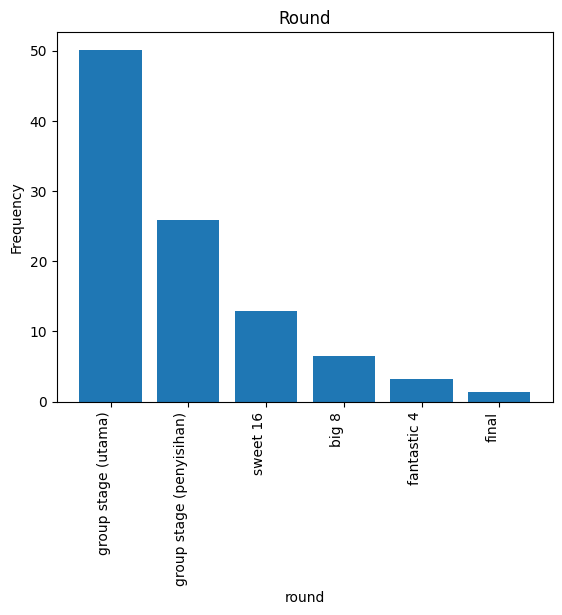

In [37]:
#univariate kategorikal
def bar_pct(home_team,away_team):
  vc = home_team.value_counts(dropna=False)
  pct = (vc/len(home_team)*100).round(2)
  plt.figure()
  plt.bar(vc.index.astype(str), pct.values)
  plt.title(away_team)
  plt.xlabel(home_team.name)
  plt.ylabel('Frequency')
  plt.xticks(rotation=90,ha='right')
  plt.show()

bar_pct(df['home_team'],'Home Team')
bar_pct(df['away_team'],'Away Team')
bar_pct(df['winner'],'Winner')
bar_pct(df['round'],'Round')

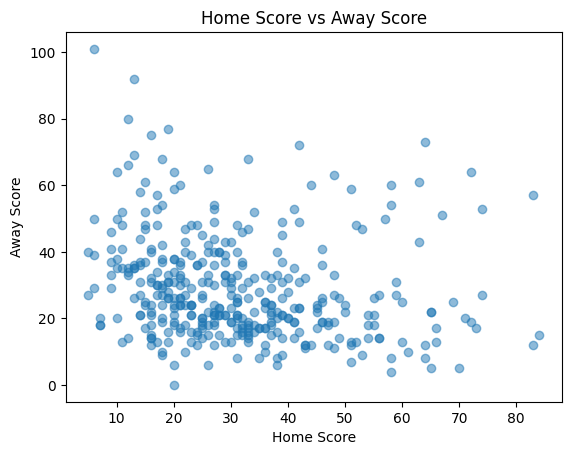

In [33]:
#bivariate numerikal vs numerikal
plt.figure()
plt.scatter(df['home_score'],df['away_score'],alpha = 0.5)
plt.title('Home Score vs Away Score')
plt.xlabel('Home Score')
plt.ylabel('Away Score')
plt.show()

/tmp/ipykernel_3547/3266848998.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups,labels=sorted(df['winner'].unique()))


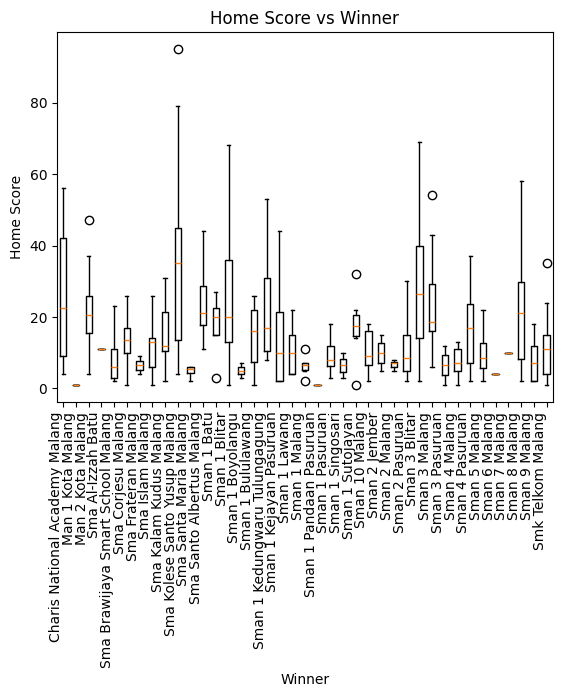

In [36]:
#bivariate numerikal vs kategorikal
groups = [df.loc[df['winner'] == w, 'margin'].dropna() for w in sorted(df['winner'].unique())]

plt.figure()
plt.boxplot(groups,labels=sorted(df['winner'].unique()))
plt.title('Home Score vs Winner')
plt.xlabel('Winner')
plt.ylabel('Home Score')
plt.xticks(rotation=90,ha='right')
plt.show()

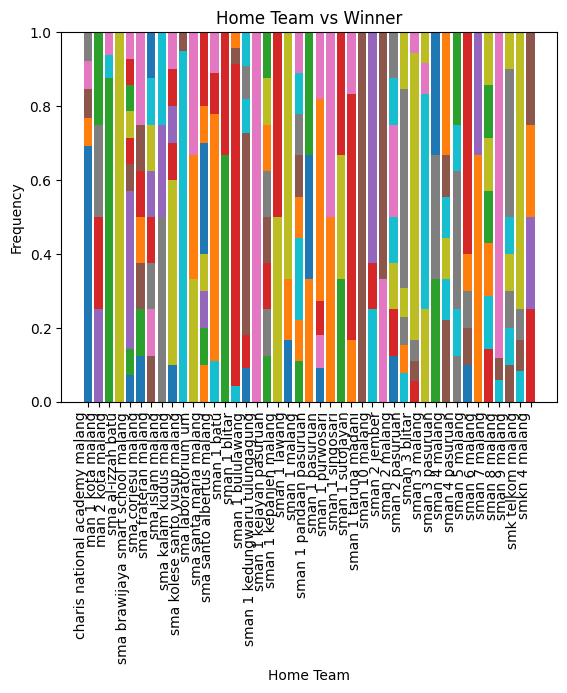

In [41]:
#bivariate kategorikal vs kategorikal
ct = pd.crosstab(df['home_team'],df['winner'], normalize = 'index')
plt.figure()
bottom = np.zeros(len(ct.index))
for col in ct.columns:
  plt.bar(ct.index.astype(str), ct[col].values, bottom=bottom, label=str(col))
  bottom += ct[col].values
plt.title('Home Team vs Winner')
plt.xlabel('Home Team')
plt.ylabel('Frequency')
plt.xticks(rotation=90,ha='right')
plt.show()

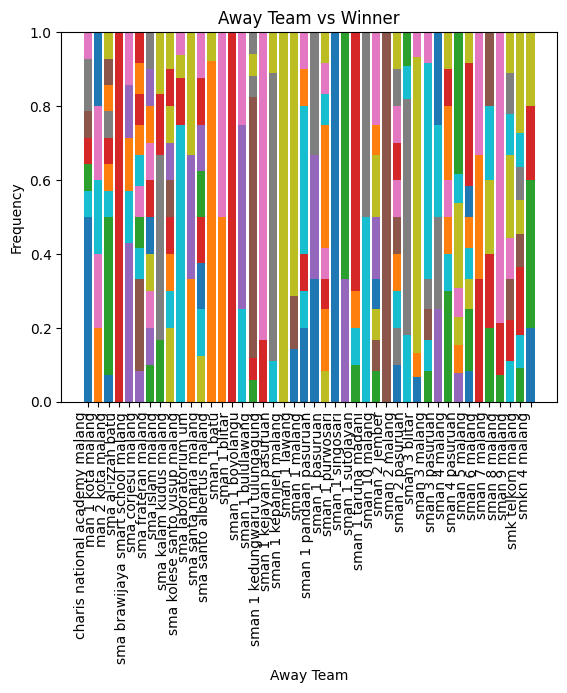

In [42]:
#bivariate kategorikal vs kategorikal
ct = pd.crosstab(df['away_team'],df['winner'], normalize = 'index')
plt.figure()
bottom = np.zeros(len(ct.index))
for col in ct.columns:
  plt.bar(ct.index.astype(str), ct[col].values, bottom=bottom, label=str(col))
  bottom += ct[col].values
plt.title('Away Team vs Winner')
plt.xlabel('Away Team')
plt.ylabel('Frequency')
plt.xticks(rotation=90,ha='right')
plt.show()